In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

from pathlib import Path
import sys
import yaml

# Project root directory
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

# Shared corpora folder (one level above all repos)
CORPORA_ROOT = PROJECT_ROOT.parents[0] / "corpora"

# Load project configuration
with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# --- Data
from src.data.data_loader import data_loader
from src.data.preprocessing import preprocessing
from src.data.export_dataframe import export_dataframe

# --- Features
from src.features.mel_filterbank import mel_filterbank
from src.features.get_MFBM import get_MFBM


INFO:src.data.data_loader:All signals have same sampling rate: 22050 Hz
INFO:src.data.preprocessing:Preprocessing completed (dc_remove=False, trim_signal=False, equal_duration=False, pre_emphasis=False, normalize=peak)


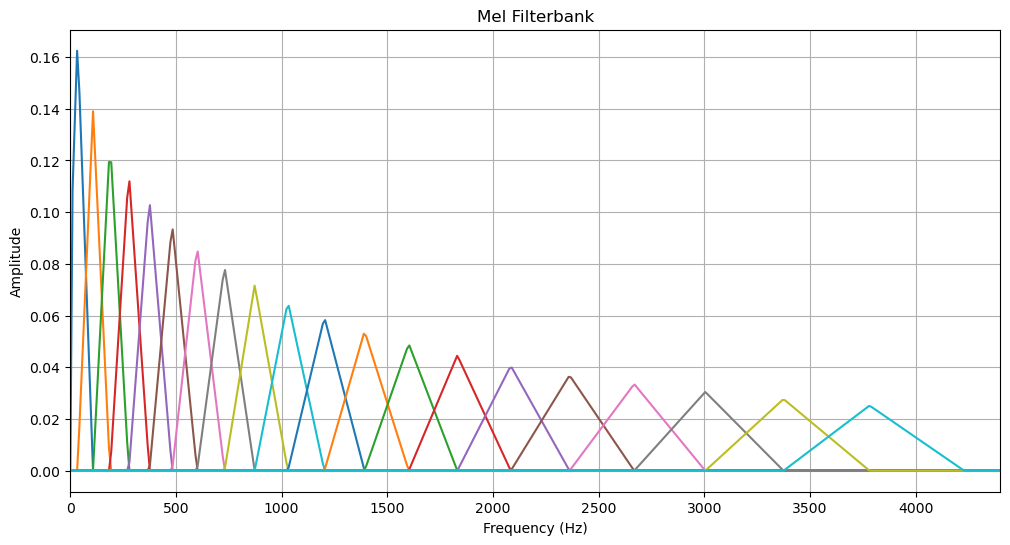

In [2]:
# --- Load data
# USP corpus, with 4 classes: Control, Edema, Nodules and Neuro

dataset_name = config["data"]["corpus_name"]

df, fs = data_loader(
    dataset_name=dataset_name,
    data_root=str(CORPORA_ROOT)
)


# Preprocessing
# Amplitude Normalization

normalize = config["audio"]["normalize"]

df = preprocessing(
    df,
    normalize=normalize
)

# --- Visualization
#df.columns

# --- Parameters
n_fft = config["features"]["n_fft"]
fmax = config["features"]["fmax"]
mel_bands = config["features"]["n_filters"]
sobrep = config["features"]["overlap"]      # filter overlap


"""
NOTE: The filter bank shown in the paper (Figure 1) incorrectly depicts 20% overlap.
The actual filter bank used in the original work — and reproduced here — uses 50% overlap,
which is consistent with the results reported in the paper.
"""

# --- Filterbank
mel_filters = mel_filterbank(
    fs,
    mel_bands,
    fmax,
    sobrep,
    n_fft,
    print_filters=True,
    save_path=str(
        PROJECT_ROOT /
        config["results"]["figures_dir"] /
        "01_mel_filterbank.png"
    )
)



In [3]:
# --- Parameters

frame_size_ms = config["features"]["frame_size_ms"]
hop_size_ms = config["features"]["hop_size_ms"]

tamanho = round(fs / 1000) * frame_size_ms   # window
passo = round(fs / 1000) * hop_size_ms       # step


# --- MEl Filterbank Magnitudes
mfbm_list = []

for sinal in df['signal']:
    mfbm = get_MFBM(
        sinal, 
        tamanho, 
        passo, 
        n_fft, 
        mel_filters
    )
    
    mfbm_list.append(mfbm)

df['MFBM'] = mfbm_list


In [4]:
# Exporting to parquet

df2 = export_dataframe(
    df,
    dataset_name,
    output_root=str(PROJECT_ROOT / "data" / "processed"),
    drop_columns=['signal', 'MFBM', 'path', 'fs']
)


# Visualization
print(df2.columns)

INFO:src.data.export_dataframe:Saved to: C:\Users\ThinK\Desktop\Github Repos\paper-voice-pathology-mfbm\data\processed\myUSP.parquet


Index(['file', 'age', 'gender', 'group', 'class', 'MFBM_0', 'MFBM_1', 'MFBM_2',
       'MFBM_3', 'MFBM_4', 'MFBM_5', 'MFBM_6', 'MFBM_7', 'MFBM_8', 'MFBM_9',
       'MFBM_10', 'MFBM_11', 'MFBM_12', 'MFBM_13', 'MFBM_14', 'MFBM_15',
       'MFBM_16', 'MFBM_17', 'MFBM_18', 'MFBM_19'],
      dtype='object')
